In [2]:
import numpy as np
import sympy as sp
from sympy.physics.mechanics import *
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

init_vprinting()

In [3]:
# Symbols
theta1, theta2 = dynamicsymbols('theta1 theta2')
t = sp.symbols('t')

# Parameters
m1, m2, l1, l2, g = sp.symbols('m1 m2 l1 l2 g')

# Point Mass

In [10]:
# Define reference frames
N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', [theta1, N.z])
B = N.orientnew('B', 'Axis', [theta2, A.z])

In [11]:
# Define Geometry
O = Point('O')
P1 = O.locatenew('P1', l1 * A.y)
P2 = P1.locatenew('P2', l2 * B.y)

In [12]:
# Define velocities
O.set_vel(N, 0)
P1.v2pt_theory(O, N, A)
P2.v2pt_theory(P1, N, B)

In [7]:
# Define Point Masses
Pa1 = Particle('P1', P1, m1)
Pa2 = Particle('P2', P2, m2)

In [8]:
# Potential and Energy
Pa1.potential_energy = -m1 * g * P1.pos_from(O).dot(N.y)
# Fix: Potential energy should be relative to the fixed frame N
Pa2.potential_energy = -m2 * g * P2.pos_from(O).dot(N.y)

# Lagrangian
L = Lagrangian(N, Pa1, Pa2)

Equations of Motion:


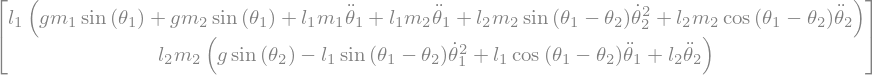

Mass Matrix:


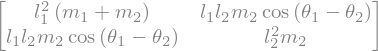

Forcing:


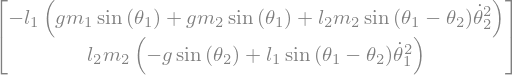

In [9]:
# Langranges Method
LM = LagrangesMethod(L, [theta1, theta2])
eom1 = LM.form_lagranges_equations()

print("Equations of Motion:")
display(sp.simplify(sp.trigsimp(eom1)))
print("Mass Matrix:")
display(sp.simplify(LM.mass_matrix))
print("Forcing:")
display(sp.trigsimp(LM.forcing))

# display(sp.trigsimp(sp.simplify(LM.rhs())))